Loading data for final test (unseen data)...
Test Set Period: 2023-06-21 to 2025-04-30
Test Set Length: 98 weeks
--------------------------------------------------
Successfully loaded model from: best_model/best_model.zip
Collected 26 portfolio values
Collected 25 action sets
Date range: 2023-06-21 00:00:00 to 2025-04-30 00:00:00

Simulation Complete. Final Portfolio Value: $13,115.20
Results DataFrame shape: (26, 4)
Results DataFrame date range: 2023-06-21 00:00:00 to 2025-04-30 00:00:00
--- Key Performance Indicators (Test Set) ---
Total Return: 31.15%
Annualized Sortino Ratio: 1.89
Max Drawdown: -27.75%
--------------------------------------------------


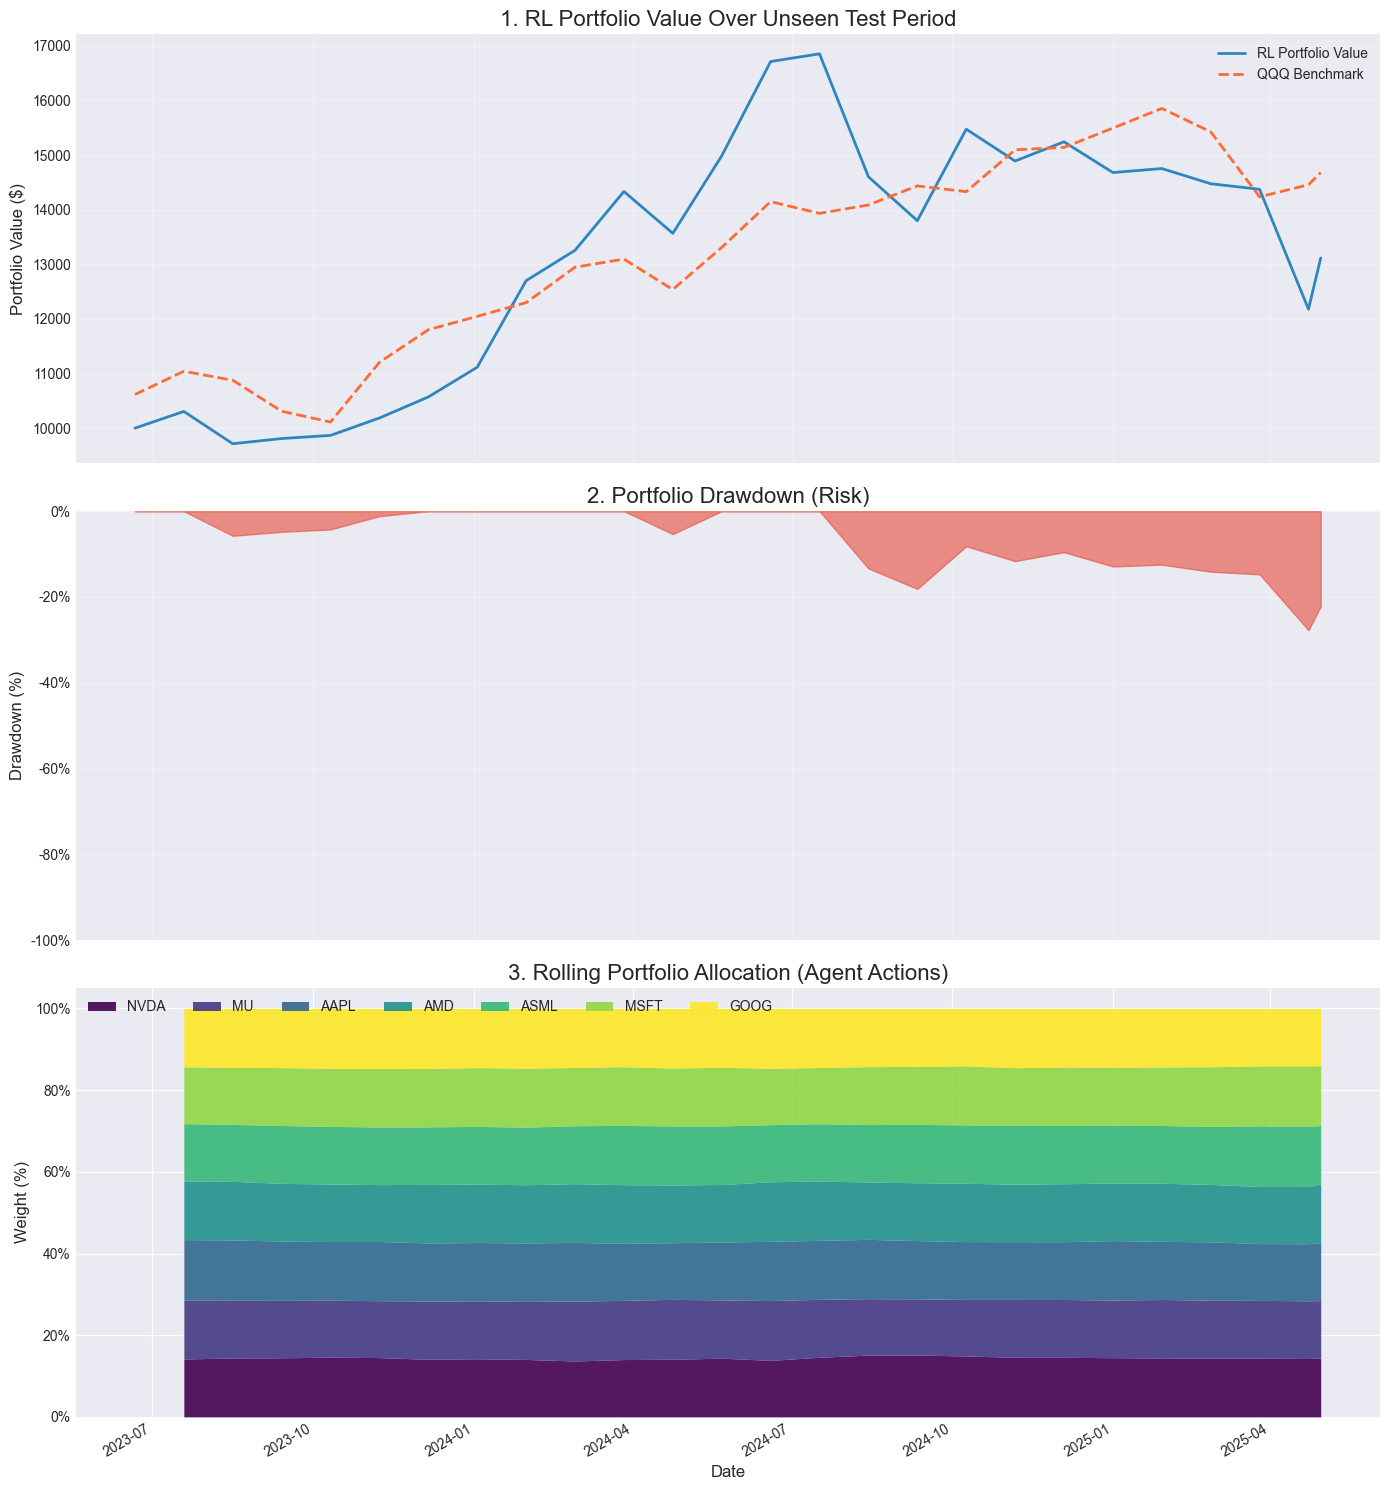


Visualization generated successfully.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from rl_system import PortfolioEnv
import math
from datetime import datetime
# Import tick formatters
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------
# 1. Configuration & Data Loading
# ---------------------------------------------------------
DATA_PATH = 'advanced_portfolio_data.csv'
MODEL_PATH = 'best_model/best_model.zip'
TICKERS = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']
REBALANCE_PERIOD = 4
INITIAL_BALANCE = 10000 # This is why the chart starts at $10,000

# Load Data and Split (Must match the split from 2_train_ppo.ipynb)
df = pd.read_csv(DATA_PATH, index_col=0)
df.index = pd.to_datetime(df.index)

n_total = len(df)
test_split_idx = int(n_total * 0.8)
test_df = df.iloc[test_split_idx:]

# Load QQQ benchmark (weekly data with monthly values forward-filled)
qqq_df = pd.read_csv('qqq_benchmark.csv', index_col=0, parse_dates=True)
# Filter QQQ to match test period
qqq_test = qqq_df.loc[test_df.index]

print(f"Loading data for final test (unseen data)...")
print(f"Test Set Period: {test_df.index.min().date()} to {test_df.index.max().date()}")
print(f"Test Set Length: {len(test_df)} weeks")
print("-" * 50)

# ---------------------------------------------------------
# 2. Backtesting Environment and Model Loading
# ---------------------------------------------------------

# Create the test environment wrapped in DummyVecEnv for model compatibility
test_env = DummyVecEnv([lambda: PortfolioEnv(
    test_df, 
    TICKERS, 
    rebalance_period=REBALANCE_PERIOD, 
    initial_balance=INITIAL_BALANCE
)])

# Load the best model saved from the last fold of the walk-forward validation
try:
    model = PPO.load(MODEL_PATH, env=test_env)
    print(f"Successfully loaded model from: {MODEL_PATH}")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Please ensure you have run 2_train_ppo.ipynb successfully.")
    exit()

# ---------------------------------------------------------
# 3. Simulation (Backtest)
# ---------------------------------------------------------

obs = test_env.reset()
done = False
portfolio_values = [INITIAL_BALANCE]  # Start with initial balance
actions_history = []
step_count = 0

# Iterate through the test data
while not done:
    # Predict action
    action, _ = model.predict(obs, deterministic=True)
    
    # Step environment (DummyVecEnv returns vectorized results)
    obs, reward, done, info = test_env.step(action)
    
    # Extract data from vectorized environment info
    # DummyVecEnv returns info as a list
    if isinstance(info, list) and len(info) > 0:
        env_info = info[0]
        if env_info and 'balance' in env_info:
            current_balance = env_info['balance'] 
            current_weights = env_info['weights']
            
            portfolio_values.append(current_balance)
            actions_history.append(current_weights)
            step_count += 1
    
    # Check for termination (DummyVecEnv returns done as array)
    if isinstance(done, (list, np.ndarray)):
        done = done[0] if len(done) > 0 else True
    if done:
        break

# Calculate dates for rebalancing periods
# The environment processes data in chunks of REBALANCE_PERIOD weeks
# So we need dates at: start, start+REBALANCE_PERIOD, start+2*REBALANCE_PERIOD, etc.
n_rebalance_periods = len(portfolio_values) - 1  # Subtract 1 for initial balance
rebalance_indices = [0] + [min(i * REBALANCE_PERIOD, len(test_df) - 1) for i in range(1, n_rebalance_periods + 1)]
step_dates = [test_df.index[idx] for idx in rebalance_indices[:len(portfolio_values)]]

# Debug: Print data collection status
print(f"Collected {len(portfolio_values)} portfolio values")
print(f"Collected {len(actions_history)} action sets")
print(f"Date range: {step_dates[0]} to {step_dates[-1]}")

# Convert results to DataFrame for easy analysis
# Ensure we have matching lengths
min_len = min(len(step_dates), len(portfolio_values))
step_dates = step_dates[:min_len]
portfolio_values = portfolio_values[:min_len]

results_df = pd.DataFrame(index=step_dates)
results_df['Portfolio Value'] = portfolio_values
results_df['Returns'] = results_df['Portfolio Value'].pct_change().fillna(0)
results_df['Cumulative Returns'] = results_df['Portfolio Value'] / INITIAL_BALANCE

# Process QQQ benchmark to align with rebalancing periods
if 'qqq_test' in locals() and len(qqq_test) > 0 and 'QQQ' in qqq_test.columns:
    try:
        # Get QQQ data at rebalancing periods (same indices as portfolio)
        qqq_rebalance_data = qqq_test.iloc[rebalance_indices[:len(portfolio_values)]]['QQQ'].values
        
        # Check if QQQ contains returns (typically between -1 and 1) or prices
        # If values are small (likely returns), compound them; otherwise calculate returns first
        if np.abs(qqq_rebalance_data).max() < 2.0:  # Likely returns
            qqq_cumulative = INITIAL_BALANCE * (1 + qqq_rebalance_data).cumprod()
        else:  # Likely prices, calculate returns first
            qqq_returns = np.diff(qqq_rebalance_data) / qqq_rebalance_data[:-1]
            qqq_returns = np.concatenate([[0], qqq_returns])  # First period has no return
            qqq_cumulative = INITIAL_BALANCE * (1 + qqq_returns).cumprod()
        
        results_df['QQQ Benchmark'] = qqq_cumulative
    except Exception as e:
        print(f"Warning: Could not process QQQ benchmark: {e}")

# Get final balance
final_balance = portfolio_values[-1] if len(portfolio_values) > 0 else INITIAL_BALANCE
print(f"\nSimulation Complete. Final Portfolio Value: ${final_balance:,.2f}")
print(f"Results DataFrame shape: {results_df.shape}")
print(f"Results DataFrame date range: {results_df.index.min()} to {results_df.index.max()}")

# ---------------------------------------------------------
# 4. Performance Metrics and Visualization
# ---------------------------------------------------------

def calculate_sortino_ratio(returns_series, risk_free_rate=0.0):
    """Calculates the annualized Sortino Ratio."""
    # We use weekly data, so 52 weeks in a year
    periods_per_year = 52
    
    # Calculate excess returns over risk-free rate
    excess_returns = returns_series - risk_free_rate / periods_per_year
    
    # Calculate downside returns (returns below 0 or the risk-free rate)
    downside_returns = excess_returns[excess_returns < 0]
    
    if len(downside_returns) == 0:
        return 999.0 # Effectively infinite sortino for perfect returns
        
    downside_std = downside_returns.std()
    
    # Annualize average excess return and downside standard deviation
    annualized_avg_excess_return = excess_returns.mean() * periods_per_year
    annualized_downside_std = downside_std * math.sqrt(periods_per_year)
    
    if annualized_downside_std == 0:
        return 999.0

    return annualized_avg_excess_return / annualized_downside_std

def calculate_max_drawdown(cumulative_returns):
    """Calculates maximum drawdown."""
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns / peak) - 1.0
    max_drawdown = drawdown.min()
    return max_drawdown

# Calculate Metrics
sortino = calculate_sortino_ratio(results_df['Returns'])
max_dd = calculate_max_drawdown(results_df['Cumulative Returns'])

print(f"--- Key Performance Indicators (Test Set) ---")
print(f"Total Return: {(results_df['Cumulative Returns'].iloc[-1] - 1) * 100:.2f}%")
print(f"Annualized Sortino Ratio: {sortino:.2f}")
print(f"Max Drawdown: {max_dd * 100:.2f}%")
print("-" * 50)

# ---------------------------------------------------------
# 5. Visualization
# ---------------------------------------------------------

# Define the formatter for percentage
percent_formatter = FuncFormatter(lambda y, _: f'{y:.0%}')

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Portfolio Value & Cumulative Returns
ax1 = axes[0]
if len(results_df) > 0:
    ax1.plot(results_df.index, results_df['Portfolio Value'], label='RL Portfolio Value', color='#2E86C1', linewidth=2)
    # Add QQQ benchmark if available
    if 'QQQ Benchmark' in results_df.columns:
        ax1.plot(results_df.index, results_df['QQQ Benchmark'], label='QQQ Benchmark', color='#FF6B35', linewidth=2, linestyle='--')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'No data to plot', ha='center', va='center', transform=ax1.transAxes)
ax1.set_title(f'1. RL Portfolio Value Over Unseen Test Period', fontsize=16)
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.tick_params(axis='y')

# 2. Drawdown
ax2 = axes[1]
if len(results_df) > 0:
    # Calculate Drawdown
    peak = results_df['Cumulative Returns'].expanding(min_periods=1).max()
    drawdown = (results_df['Cumulative Returns'] / peak) - 1.0
    ax2.fill_between(drawdown.index, 0, drawdown, color='#E74C3C', alpha=0.6)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'No data to plot', ha='center', va='center', transform=ax2.transAxes)
ax2.set_title('2. Portfolio Drawdown (Risk)', fontsize=16)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_ylim(-1.0, 0)
# FIXED: Use set_major_formatter to apply percentage formatting
ax2.yaxis.set_major_formatter(percent_formatter)


# 3. Rolling Allocation (Actions)
ax3 = axes[2]
# Convert actions history to DataFrame
# Use dates starting from first rebalancing period (skip initial balance)
if len(actions_history) > 0:
    action_dates = step_dates[1:] if len(step_dates) > 1 else step_dates
    # Ensure dates match actions_history length
    if len(action_dates) != len(actions_history):
        action_dates = step_dates[:len(actions_history)+1][1:] if len(step_dates) > len(actions_history) else step_dates[1:len(actions_history)+1]
    
    actions_df = pd.DataFrame(actions_history, index=action_dates[:len(actions_history)], columns=TICKERS)
    actions_df.plot.area(ax=ax3, linewidth=0, cmap='viridis', alpha=0.9)
    ax3.set_title('3. Rolling Portfolio Allocation (Agent Actions)', fontsize=16)
    ax3.set_ylabel('Weight (%)', fontsize=12)
    # FIXED: Use set_major_formatter to apply percentage formatting
    ax3.yaxis.set_major_formatter(percent_formatter)
    ax3.legend(loc='upper left', ncol=len(TICKERS))
    ax3.set_xlabel('Date', fontsize=12)


plt.tight_layout()
plt.show()

print("\nVisualization generated successfully.")

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from rl_system import PortfolioEnv

# 1. Load Data and Model
df = pd.read_csv('advanced_portfolio_data.csv', index_col=0)
split_idx = int(len(df) * 0.8)
test_df = df.iloc[split_idx:]
tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG']

# Load QQQ benchmark (weekly data with monthly values forward-filled)
qqq_df = pd.read_csv('qqq_benchmark.csv', index_col=0, parse_dates=True)
# Filter QQQ to match test period
qqq_test = qqq_df.loc[test_df.index]

model = PPO.load('best_model/best_model')

# 2. Run Backtest
lookback_window = 12  # Default lookback_window from PortfolioEnv
env_test = PortfolioEnv(test_df, tickers, rebalance_period=4)
obs, _ = env_test.reset()
done = False

history = {'total_value': [], 'actions': []}

# Include initial balance
history['total_value'].append(10000)  # Initial balance

print("Running Backtest...")
while not done:
    # Predict action using the trained model
    # deterministic=True ensures we take the best action, not a random one
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, done, truncated, info = env_test.step(action)
    
    history['total_value'].append(info['balance'])
    # We softmax the action here just to visualize the actual weights used
    weights = np.exp(action - np.max(action))
    weights = weights / weights.sum()
    history['actions'].append(weights)

Running Backtest...


In [10]:
# 3. Process Buy-and-Hold Benchmark (Equal Weight)
# Get raw returns for all assets
raw_ret_cols = [c for c in test_df.columns if '_raw_ret' in c]
buy_hold_returns = test_df[raw_ret_cols].values

# Equal weight: 1/7 for each asset
equal_weights = np.ones(len(tickers)) / len(tickers)

# Calculate portfolio returns: equal-weighted average of ALL weekly returns
buy_hold_portfolio_returns = buy_hold_returns @ equal_weights

# Start from lookback_window to match RL
buy_hold_returns_aligned = buy_hold_portfolio_returns[lookback_window:]

# IMPORTANT: Compound ALL weekly returns (not just every 4th!)
# This simulates true buy-and-hold that experiences all market movements
# The RL agent compounds through all 4 weeks in each period, so buy-and-hold should too
buy_hold_cumulative_all_weeks = (1 + buy_hold_returns_aligned).cumprod() * 10000

# Now sample at rebalancing periods (every 4 weeks) for plotting alignment
# This gives us the value at the same times RL records its balance
buy_hold_cumulative = buy_hold_cumulative_all_weeks[::4]

# 4. Process QQQ Benchmark
# RL starts processing from lookback_window (12 weeks), so we need to account for that
# Since RL rebalances every 4 weeks, we take every 4th value starting from lookback_window
# Start QQQ from lookback_window to match when RL starts consuming data
qqq_start_idx = lookback_window
# Take every 4th value (monthly rebalancing) starting from lookback_window
qqq_monthly_returns = qqq_test['QQQ'].iloc[qqq_start_idx::4].values

# Calculate cumulative value starting from $10,000
qqq_cumulative = (1 + qqq_monthly_returns).cumprod() * 10000

# Ensure QQQ has same length as RL curve (RL curve includes initial balance + steps)
rl_curve = np.array(history['total_value'])
if len(qqq_cumulative) > len(rl_curve) - 1:  # -1 because RL includes initial balance
    qqq_aligned = qqq_cumulative[:len(rl_curve) - 1]
elif len(qqq_cumulative) < len(rl_curve) - 1:
    # Pad with last value if needed
    qqq_aligned = np.pad(qqq_cumulative, (0, len(rl_curve) - 1 - len(qqq_cumulative)), mode='edge')
else:
    qqq_aligned = qqq_cumulative

# Prepend initial $10,000 to QQQ to match RL curve structure
qqq_aligned = np.concatenate([[10000], qqq_aligned])

# Align Buy-and-Hold to match RL curve length
if len(buy_hold_cumulative) > len(rl_curve) - 1:
    buy_hold_aligned = buy_hold_cumulative[:len(rl_curve) - 1]
elif len(buy_hold_cumulative) < len(rl_curve) - 1:
    # Pad with last value if needed
    buy_hold_aligned = np.pad(buy_hold_cumulative, (0, len(rl_curve) - 1 - len(buy_hold_cumulative)), mode='edge')
else:
    buy_hold_aligned = buy_hold_cumulative

# Prepend initial $10,000 to Buy-and-Hold to match RL curve structure
buy_hold_aligned = np.concatenate([[10000], buy_hold_aligned])

# 5. Process Results
# Align lengths (The env consumes 4 steps at a time, so we need to align indices carefully for plotting)
# For simplicity in plotting, we will plot the RL steps against the timeframe
time_steps = np.linspace(0, len(test_df), len(rl_curve))

# 6. Visualization
plt.figure(figsize=(12, 8))

# Plot 1: Equity Curve
plt.subplot(2, 1, 1)
plt.plot(rl_curve, label='PPO Agent', color='blue', linewidth=2)
plt.plot(qqq_aligned, label='QQQ Benchmark', color='orange', linewidth=2, linestyle='--')
plt.plot(buy_hold_aligned, label='Buy & Hold (Equal Weight)', color='green', linewidth=2, linestyle=':')
plt.title("Backtest: PPO Agent vs Benchmarks")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Asset Allocation (Stackplot)
plt.subplot(2, 1, 2)
actions = np.array(history['actions'])
plt.stackplot(range(len(actions)), actions.T, labels=tickers, alpha=0.8)
plt.title("Agent Asset Allocation Over Time")
plt.xlabel("Rebalancing Periods (Months)")
plt.ylabel("Weight")
plt.legend(loc='upper left')
plt.margins(0,0)

plt.tight_layout()
plt.show()

# 7. Metrics
total_return = (rl_curve[-1] - 10000) / 10000 * 100
qqq_return = (qqq_aligned[-1] - 10000) / 10000 * 100
buy_hold_return = (buy_hold_aligned[-1] - 10000) / 10000 * 100
print(f"PPO Agent Total Return: {total_return:.2f}%")
print(f"QQQ Benchmark Total Return: {qqq_return:.2f}%")
print(f"Buy & Hold (Equal Weight) Total Return: {buy_hold_return:.2f}%")
print(f"Excess Return vs QQQ: {total_return - qqq_return:.2f}%")
print(f"Excess Return vs Buy & Hold: {total_return - buy_hold_return:.2f}%")

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 7 is different from 0)

In [3]:
# 8. Rebalancing Activity Analysis
actions_array = np.array(history['actions'])
if len(actions_array) > 1:
    # Calculate turnover (how much weights change between periods)
    weight_changes = np.diff(actions_array, axis=0)
    turnover_per_period = np.sum(np.abs(weight_changes), axis=1)
    avg_turnover = np.mean(turnover_per_period)
    max_turnover = np.max(turnover_per_period)
    
    # Calculate how far from equal weight the agent stays
    equal_weight = np.ones(len(tickers)) / len(tickers)
    deviations_from_equal = np.mean([np.sum(np.abs(w - equal_weight)) for w in actions_array])
    
    print(f"\n--- Rebalancing Activity ---")
    print(f"Average Turnover per Period: {avg_turnover*100:.2f}%")
    print(f"Max Turnover in Single Period: {max_turnover*100:.2f}%")
    print(f"Avg Deviation from Equal Weight: {deviations_from_equal*100:.2f}%")
    print(f"Number of Rebalancing Periods: {len(actions_array)}")
    
    # Show weight statistics
    print(f"\n--- Weight Statistics ---")
    for i, ticker in enumerate(tickers):
        weights_for_ticker = actions_array[:, i]
        print(f"{ticker}: Mean={np.mean(weights_for_ticker)*100:.1f}%, "
              f"Std={np.std(weights_for_ticker)*100:.1f}%, "
              f"Min={np.min(weights_for_ticker)*100:.1f}%, "
              f"Max={np.max(weights_for_ticker)*100:.1f}%")


--- Rebalancing Activity ---
Average Turnover per Period: 30.30%
Max Turnover in Single Period: 54.82%
Avg Deviation from Equal Weight: 32.13%
Number of Rebalancing Periods: 22

--- Weight Statistics ---
NVDA: Mean=13.7%, Std=5.1%, Min=9.6%, Max=30.4%
MU: Mean=19.9%, Std=8.0%, Min=8.5%, Max=29.9%
AAPL: Mean=12.1%, Std=2.9%, Min=9.5%, Max=21.1%
AMD: Mean=12.2%, Std=2.7%, Min=9.0%, Max=18.8%
ASML: Mean=14.0%, Std=5.0%, Min=9.5%, Max=23.9%
MSFT: Mean=13.2%, Std=3.7%, Min=8.6%, Max=21.3%
GOOG: Mean=15.0%, Std=6.1%, Min=8.5%, Max=26.2%


In [4]:
# 9. Transaction Cost Analysis
# Estimate total transaction costs paid
actions_array = np.array(history['actions'])
total_turnover_cost = 0
for i in range(len(actions_array) - 1):
    turnover = np.sum(np.abs(actions_array[i+1] - actions_array[i]))
    # Estimate cost: assume average balance during period
    avg_balance = (rl_curve[i] + rl_curve[i+1]) / 2
    cost = avg_balance * turnover * 0.0010  # 10bps
    total_turnover_cost += cost

print(f"\n--- Transaction Cost Impact ---")
print(f"Estimated Total Transaction Costs: ${total_turnover_cost:.2f}")
print(f"Transaction Costs as % of Final Value: {(total_turnover_cost/rl_curve[-1])*100:.2f}%")
print(f"If no rebalancing (buy-and-hold): Final value would be ${buy_hold_aligned[-1]:.2f}")
print(f"PPO Agent Final Value: ${rl_curve[-1]:.2f}")
print(f"Difference: ${rl_curve[-1] - buy_hold_aligned[-1]:.2f}")


# 10. Risk-Adjusted Performance
def calculate_sharpe_ratio(returns, risk_free_rate=0.04):
    """Calculate annualized Sharpe ratio"""
    if len(returns) == 0 or np.std(returns) == 0:
        return 0
    # Annualize: multiply by sqrt(12) for monthly data
    excess_returns = returns - risk_free_rate/12
    return np.sqrt(12) * np.mean(excess_returns) / np.std(returns)

# Calculate returns for each strategy
rl_returns = np.diff(rl_curve) / rl_curve[:-1]
qqq_returns = np.diff(qqq_aligned) / qqq_aligned[:-1]
buy_hold_returns = np.diff(buy_hold_aligned) / buy_hold_aligned[:-1]

print(f"\n--- Risk-Adjusted Performance ---")
print(f"PPO Agent Sharpe Ratio: {calculate_sharpe_ratio(rl_returns):.3f}")
print(f"QQQ Sharpe Ratio: {calculate_sharpe_ratio(qqq_returns):.3f}")
print(f"Buy & Hold Sharpe Ratio: {calculate_sharpe_ratio(buy_hold_returns):.3f}")
print(f"\nPPO Agent Volatility: {np.std(rl_returns)*np.sqrt(12)*100:.2f}% (annualized)")
print(f"QQQ Volatility: {np.std(qqq_returns)*np.sqrt(12)*100:.2f}% (annualized)")
print(f"Buy & Hold Volatility: {np.std(buy_hold_returns)*np.sqrt(12)*100:.2f}% (annualized)")


--- Transaction Cost Impact ---
Estimated Total Transaction Costs: $103.78
Transaction Costs as % of Final Value: 0.53%
If no rebalancing (buy-and-hold): Final value would be $19476.29
PPO Agent Final Value: $19491.11
Difference: $14.82

--- Risk-Adjusted Performance ---
PPO Agent Sharpe Ratio: 1.612
QQQ Sharpe Ratio: 1.882
Buy & Hold Sharpe Ratio: 1.451

PPO Agent Volatility: 21.89% (annualized)
QQQ Volatility: 13.87% (annualized)
Buy & Hold Volatility: 24.71% (annualized)
